<a href="https://colab.research.google.com/github/Himanshu-86/ML_2026/blob/main/Practical_04_Titanic_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 04: Titanic Survival Prediction

## Dataset: Titanic Dataset
## Subject: Machine Learning

Objective: Predict survival of passengers using classification techniques.


## Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Splitting data and scaling features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model and Evaluation Metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Load Dataset

In [ ]:
# Load the raw dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Display the initial rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Data Cleaning

Data Cleaning & Preprocessing
Note: Here, we handle missing values, drop irrelevant features that won't help the model, and convert categorical variables into numerical values using One-Hot Encoding.

In [ ]:
# Drop columns that are unique identifiers or text-heavy and uninformative for basic logistic regression
df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1, inplace=True)

# Handle missing values: fill Age with the column mean
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Handle missing values: fill Embarked with the most frequent value (mode)
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Convert categorical variables (Sex and Embarked) into dummy/indicator variables
df = pd.get_dummies(df, columns=["Sex", "Embarked"])

# Preview the cleaned dataset
df.head()

/tmp/ipykernel_58044/3268565124.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)
/tmp/ipykernel_58044/3268565124.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,False,True,False,False,True
1,1,1,38.0,1,0,71.2833,True,False,True,False,False
2,1,3,26.0,0,0,7.9250,True,False,False,False,True
3,1,1,35.0,1,0,53.1000,True,False,False,False,True
4,0,3,35.0,0,0,8.0500,False,True,False,False,True


## Feature & Target Split
Note: Separate the target label (Survived) from the feature columns used for training.

In [ ]:
# X contains independent features, y contains the target label
X = df.drop("Survived", axis=1)
y = df["Survived"]

## Train-Test Split
Note: We reserve 25% of the data to test our model's performance and use the remaining 75% for training.

In [ ]:
# Split dataset into training and testing sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Feature Scaling
Note: Standardizing features ensures that variables with larger ranges (like Fare) do not disproportionately dominate the Logistic Regression model.

In [ ]:
# Initialize the StandardScaler
sc = StandardScaler()

# Fit on training data and transform both training and testing sets
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Model Training (Logistic Regression)
Note: Train a baseline Logistic Regression classifier on our scaled training dataset.

In [ ]:
# Instantiate the Logistic Regression model
model = LogisticRegression()

# Train the model
model.fit(X_train, y_train)

LogisticRegression()

## Prediction
Note: Generate predictions on the unseen test set and evaluate performance using Accuracy and a Confusion Matrix.

In [ ]:
# Predict survival for the test features
y_pred = model.predict(X_test)

## Evaluation

In [ ]:
# Calculate performance metrics
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

# Print evaluation summary
print("Accuracy:", acc)
print("Confusion Matrix:\n", cm)

Accuracy: 0.8071748878923767
Confusion Matrix:
 [[115  19]
 [ 24  65]]


## Confusion Matrix Visualization

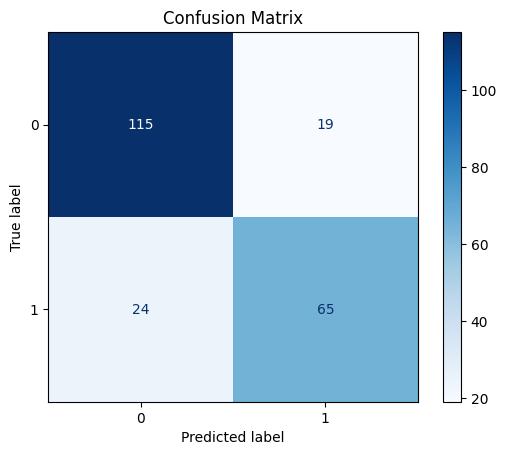

In [ ]:
# Visualizing the Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


## Data Visualization

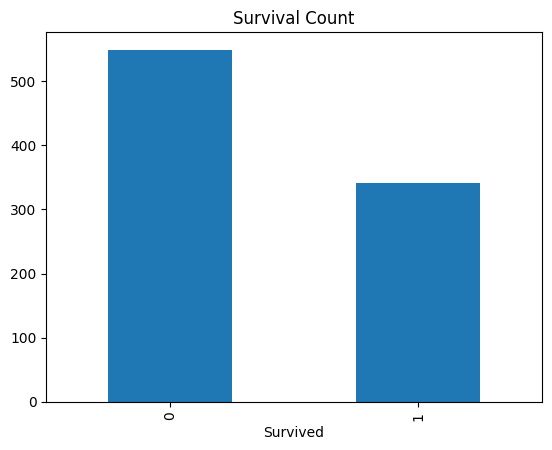

In [ ]:
plt.figure()
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.show()

## Conclusion

Logistic Regression was successfully applied to predict passenger survival. Data preprocessing and feature engineering improved model performance, achieving good classification accuracy.